# Notebook 1: BDG2 Data Exploration

This notebook explores Building Data Genome Project 2 dataset.
Prepares building electricity demand profiles for multiagent energy management experiment.

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

Adding all the directories and filepath setups so we can access our dataset.

In [28]:
PROJ_DIR=Path(r"C:\Users\prish\building-data-genome-project-2")

DATA_DIR=PROJ_DIR / "data"

METADATA_FILE = DATA_DIR / "metadata" / "metadata.csv"
ELECTRICITY_FILE = DATA_DIR / "meters" / "cleaned" / "electricity_cleaned.csv"
SOLAR_FILE = DATA_DIR / "meters" / "cleaned" / "solar_cleaned.csv"

PROCESSED_DIR = PROJ_DIR / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)   #creating directory for procesed data

print(PROJ_DIR.exists())
print(METADATA_FILE.exists())
print(ELECTRICITY_FILE.exists())

True
True
True


Understanding the buildings and meters. The different kinds of building in the dataset, so we can choose 2 buildings later.

In [29]:
metadata=pd.read_csv(METADATA_FILE)  
bldgdata=metadata["primaryspaceusage"].value_counts();
print(bldgdata)

primaryspaceusage
Education                        617
Office                           307
Entertainment/public assembly    204
Lodging/residential              168
Public services                  166
Other                             29
Healthcare                        29
Parking                           24
Warehouse/storage                 15
Manufacturing/industrial          13
Retail                            12
Services                          11
Technology/science                 7
Food sales and service             6
Utility                            4
Religious worship                  3
Name: count, dtype: int64


Choosing 2 suitable buildings: Residential, on a site with good solar

In [30]:
residential=metadata[metadata.primaryspaceusage.str.contains("resid",case=False,na=False)]

solar_ids=pd.read_csv(SOLAR_FILE,nrows=0).columns[1:]  #headers only (building ids)
solar_sites=metadata.loc[metadata.building_id.isin(solar_ids),"site_id"].unique();
candidates=residential[residential.site_id.isin(solar_sites)]

elec_cols=["timestamp"] + list(candidates.building_id)
elec = pd.read_csv(ELECTRICITY_FILE, usecols=elec_cols, parse_dates=["timestamp"], index_col="timestamp")

completeness=elec.notna().mean().sort_values(ascending=False);
building_a, building_b = completeness.index[:2]
demand=elec[[building_a,building_b]]


site_id = candidates.set_index("building_id").loc[building_a, "site_id"]


Extracting solar for that site

In [31]:
solar_pool=metadata[(metadata.site_id==site_id) & (metadata.building_id.isin(solar_ids))].building_id
solar=pd.read_csv(SOLAR_FILE,usecols=["timestamp"]+list(solar_pool),parse_dates=["timestamp"],index_col="timestamp")
solar_id=solar.notna().mean().idxmax()
solar=solar[[solar_id]]

Checking for missing values/anomalies

In [33]:
df = demand.join(solar, how="inner")
df.columns = ["building_a", "building_b", "solar"]

print("Missing:\n", df.isna().sum())

df = demand.join(solar, how="inner")
df.columns = ["building_a", "building_b", "solar"]

print("Missing:\n", df.isna().sum())

for col in df.columns:
    mu, sigma = df[col].mean(), df[col].std()
    bad = (df[col] < 0) | ((df[col] - mu).abs() > 5 * sigma)
    print(col, "anomalies:", bad.sum())
    df.loc[bad, col] = np.nan   # convert anomalies to gaps, handle in next step

Missing:
 building_a    1043
building_b    1044
solar          370
dtype: int64
Missing:
 building_a    1043
building_b    1044
solar          370
dtype: int64
building_a anomalies: 0
building_b anomalies: 0
solar anomalies: 0


Aligning the time series (trimming to full coverage).

(16540, 3) 2016-01-01 00:00:00 -> 2017-12-31 23:00:00


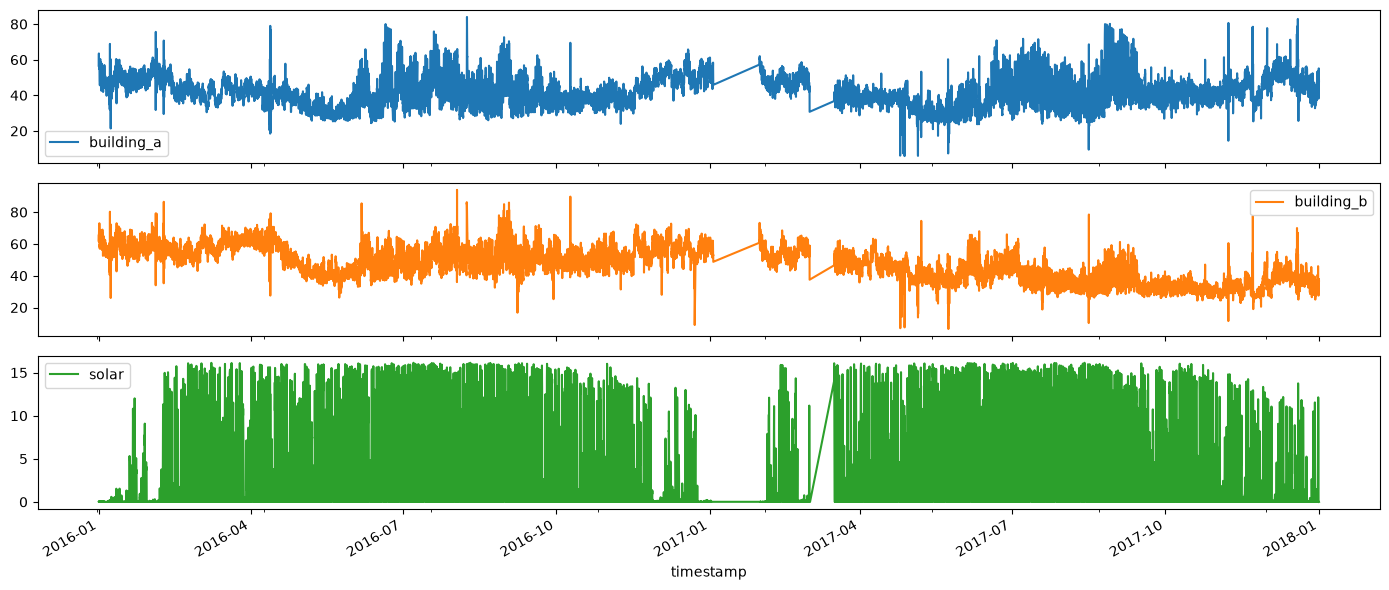

In [34]:
df = df.interpolate(method="time", limit=6)          # fill gaps up to 6h
valid = df.notna().all(axis=1)
df = df.loc[valid[valid].index.min(): valid[valid].index.max()].dropna()

print(df.shape, df.index.min(), "->", df.index.max())
df.plot(subplots=True, figsize=(14, 6)); plt.tight_layout(); plt.show()

In [35]:
df.to_csv(PROCESSED_DIR / "bdg2_clean.csv", index_label="timestamp")
print("Saved:", PROCESSED_DIR / "bdg2_clean.csv")

Saved: C:\Users\prish\building-data-genome-project-2\data\processed\bdg2_clean.csv


In [36]:
is_zero = (df["solar"] == 0)
run_id = (is_zero != is_zero.shift()).cumsum()
zero_runs = df[is_zero].groupby(run_id).size()

print("Longest zero run (hours):", zero_runs.max())
print("Runs longer than 48h:", (zero_runs > 48).sum())

Longest zero run (hours): 16
Runs longer than 48h: 0


In [37]:
long_zero_runs = zero_runs[zero_runs > 48].index
mask = is_zero & run_id.isin(long_zero_runs)
df.loc[df.index[mask], "solar"] = np.nan

print("New missing % per column:\n", df.isna().mean() * 100)

New missing % per column:
 building_a    0.0
building_b    0.0
solar         0.0
dtype: float64


In [38]:
df_interp = df.interpolate(method="time", limit=6)
full_idx = pd.date_range(df_interp.index.min(), df_interp.index.max(), freq="h")
present = pd.Series(full_idx.isin(df_interp.dropna().index), index=full_idx)

run_id2 = (present != present.shift(1).fillna(present.iloc[0])).cumsum()
run_lengths = present.groupby(run_id2).sum()
best_run = run_lengths.idxmax()

df_clean = df_interp.reindex(full_idx)[(run_id2 == best_run) & present].dropna()

print(f"Longest contiguous stretch: {len(df_clean)} hours (~{len(df_clean)/24:.0f} days)")
print("Range:", df_clean.index.min(), "->", df_clean.index.max())
print("Truly contiguous:", (df_clean.index.to_series().diff()[1:] == pd.Timedelta("1h")).all())

Longest contiguous stretch: 8575 hours (~357 days)
Range: 2016-01-01 00:00:00 -> 2016-12-23 06:00:00
Truly contiguous: True


array([<Axes: >, <Axes: >, <Axes: >], dtype=object)

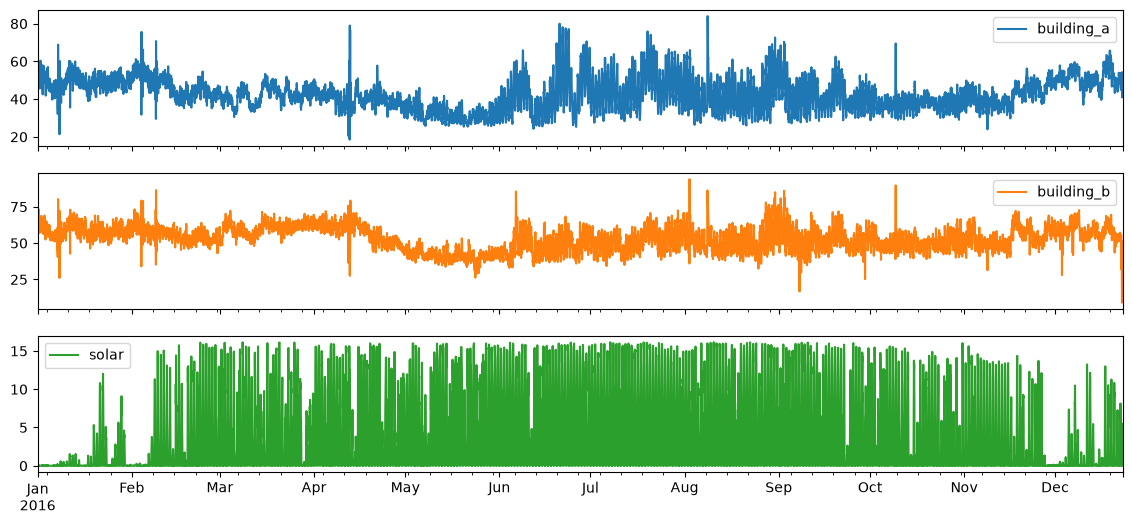

In [39]:
df_clean.plot(subplots=True, figsize=(14, 6))

In [40]:
df_clean.to_csv(PROCESSED_DIR / "bdg2_clean.csv", index_label="timestamp")
print("Saved:", PROCESSED_DIR / "bdg2_clean.csv")

Saved: C:\Users\prish\building-data-genome-project-2\data\processed\bdg2_clean.csv
